# Taxi 요금 데이터 전처리 프로젝트

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
raw = pd.read_csv('trip.csv')
raw.shape


(22701, 9)

택시 요금 예측을 위해 데이터를 불러오고,  
분석과 시각화에 필요한 라이브러리를 먼저 준비한다.

## Part 1. 데이터 로드 및 구조 확인


In [ ]:
data = pd.read_csv('trip.csv')
data.head() 

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


데이터의 일부를 확인,  
전체 컬럼 구성과 데이터 형태를 간단히 살펴봄.  
요금('fare_amount`)을 예측 대상으로 설정하고,  
거리와 시간, 승객 수 등이 영향을 줄 수 있을 것으로 판단했다.

In [12]:
data.select_dtypes(include='number').columns


Index(['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount',
       'tolls_amount'],
      dtype='object')

## Part 2. 데이터 전처리
   ### 2-1 결측치 처리
   

In [13]:
data.isnull().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              3
tip_amount               0
tolls_amount             0
dtype: int64

이상치 확인을 위해 수치형 변수만 선택하고,  
각 컬럼의 결측치 개수를 확인하였다.  
요금(fare amount) 컬럼에서만 소수의 결측치가 존재함을 확인했다.

In [10]:
data.isnull().mean()


passenger_name           0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
payment_method           0.000000
passenger_count          0.000000
trip_distance            0.000000
fare_amount              0.000132
tip_amount               0.000000
tolls_amount             0.000000
dtype: float64

In [11]:
(data.isnull().mean() * 100).sort_values(ascending=False)


fare_amount              0.013215
passenger_name           0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
payment_method           0.000000
passenger_count          0.000000
trip_distance            0.000000
tip_amount               0.000000
tolls_amount             0.000000
dtype: float64

컬럼별 결측치 비율을 확인하였다.  
대부분의 변수는 결측치가 없었으며,  
요금(fareamount) 컬럼에서만 약 0.01% 수준의 결측치가 존재함을 확인했다.


In [14]:
data[data['fare_amount'].isnull()]


,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
52,Benjamin Johnson,04/04/2017 4:22:03 PM,04/04/2017 4:35:30 PM,Cash,1,2.20,NaN,0.0,0.00
189,Maria Ibarra,08/21/2017 12:40:25 PM,08/21/2017 1:12:31 PM,Debit Card,3,15.20,NaN,5.0,0.00
244,Tina Avila,08/09/2017 8:32:09 AM,08/09/2017 9:31:11 AM,Cash,1,15.89,NaN,10.0,5.76


In [15]:
data = data.dropna(subset=['fare_amount'])


In [16]:
data['fare_amount'].isnull().sum()


np.int64(0)

요금(fareamount) 컬럼의 결측치가 포함된 행을 직접 확인하였다.  
요금은 예측 대상 변수이므로,  
결측치가 존재하는 행은 분석에서 제외하였다.  
처리 이후 요금 컬럼에는 결측치가 남아있지 않음을 확인했다.


### 2-2 이상치 처리

In [17]:
data[['passenger_count',
      'trip_distance',
      'fare_amount',
      'tip_amount',
      'tolls_amount']].describe()


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000
mean,1.643581,2.912318,13.024009,1.835327,0.312302
std,1.304983,3.651335,13.240074,2.800093,1.398775
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


수치형 변수의 요약 통계를 통해  
요금(fareamount)과 승객 수(passenger count)에서  
비정상적인 값이 존재함을 확인하였다.  

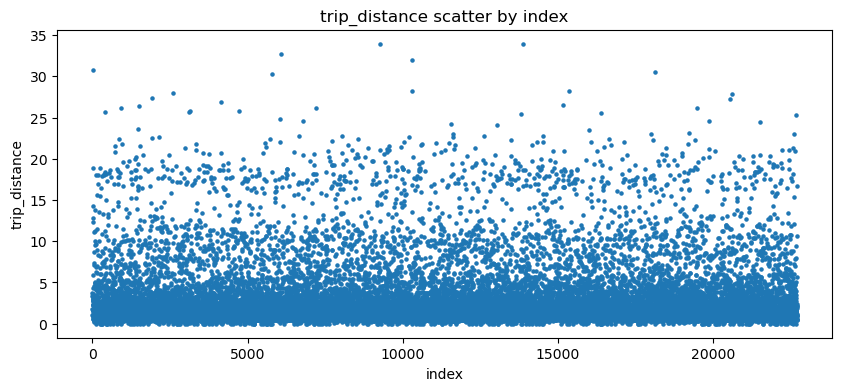

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.scatter(data.index, data['trip_distance'], s=5)
plt.title('trip_distance scatter by index')
plt.xlabel('index')
plt.ylabel('trip_distance')
plt.show()


요금에 직접적인 영향을 주는 변수인  
주행 거리(tripdistance)를 중심으로 이상치를 추가로 확인하였다.

index와 주행 거리(trip distance) 간의 산점도를 통해  
비정상적으로 큰 값이 존재하는지 확인하였다.

In [22]:
data = data[data['fare_amount'] > 0]

data = data[(data['passenger_count'] >= 1) & (data['passenger_count'] <= 6)]

data = data[~((data['trip_distance'] == 0) & (data['fare_amount'] > 0))]


요약 통계와 산점도를 통해 확인한 이상치를 바탕으로,  
현실적으로 의미가 없는 값을 조건으로 제거하였다.  
요금이 0 이하인 경우, 비정상적인 승객 수,  
이동 거리는 없으나 요금이 발생한 경우를 이상치로 판단하였다.


In [23]:
data[['passenger_count',
      'trip_distance',
      'fare_amount',
      'tip_amount',
      'tolls_amount']].describe()


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22501.000000,22501.000000,22501.000000,22501.000000,22501.000000
mean,1.645882,2.932710,12.974762,1.830778,0.309262
std,1.285585,3.655873,12.668360,2.767519,1.385330
min,1.000000,0.010000,0.010000,0.000000,0.000000
25%,1.000000,1.000000,6.500000,0.000000,0.000000
50%,1.000000,1.630000,9.500000,1.360000,0.000000
75%,2.000000,3.100000,14.500000,2.450000,0.000000
max,6.000000,33.960000,999.990000,200.000000,19.100000


이상치 제거 이후 수치형 변수들의 분포가  
보다 안정적인 범위로 정리되었음을 확인하였다.


In [24]:
data.shape


(22501, 9)

### 2-3. 파생 변수 및 범주 정리

이 단계에서 요금 예측에 도움이 될 수 있는  
추가 변수를 생성하고, 범주형 변수를 단순화하였다.

In [26]:
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])


승차 및 하차 시간 정보를 활용하여  
주행 시간(trip duration min) 변수를 새로 생성하였다.

In [27]:
data['trip_duration_min'] = (
    data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']
).dt.total_seconds() / 60


In [28]:
data = data[data['trip_duration_min'] > 0]


주행 시간이 0 이하인 데이터는  
실제 이동으로 보기 어려워 제거하였다.

### 결제수단 범주 정리


In [29]:
data['payment_method'].value_counts()


payment_method
Cash           11096
Debit Card      5730
Credit Card     5674
Name: count, dtype: int64

In [30]:
data['payment_method'] = data['payment_method'].replace(
    ['Credit Card', 'Debit Card'], 'Card'
)


In [31]:
data[['trip_duration_min','trip_distance','fare_amount']].describe()
data['payment_method'].value_counts()


payment_method
Card    11404
Cash    11096
Name: count, dtype: int64

카드 결제 방식(Credit Card, Debit Card)은  
하나의 범주(Card)로 통합하였다.

# 3. EDA
  ## 3-1 수치형 변수 기초 통계 

In [34]:
num_cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'trip_duration_min',
    'tip_amount',
    'tolls_amount'
]

data[num_cols].describe()


,passenger_count,trip_distance,fare_amount,trip_duration_min,tip_amount,tolls_amount
count,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000
mean,1.645911,2.932587,12.974094,17.065238,1.830859,0.309276
std,1.285606,3.655908,12.668246,61.568071,2.767554,1.385359
min,1.000000,0.010000,0.010000,0.016667,0.000000,0.000000
25%,1.000000,1.000000,6.500000,6.733333,0.000000,0.000000
50%,1.000000,1.630000,9.500000,11.233333,1.360000,0.000000
75%,2.000000,3.092500,14.500000,18.450000,2.450000,0.000000
max,6.000000,33.960000,999.990000,1439.550000,200.000000,19.100000


요금 예측에 활용될 수치형 변수들의 기초 통계를 확인하여  
각 변수의 분포와 값의 범위를 파악하였다.

### 3-2 요금과 주요 변수 간 관계분석
   #### 요금과 주행거리 관계


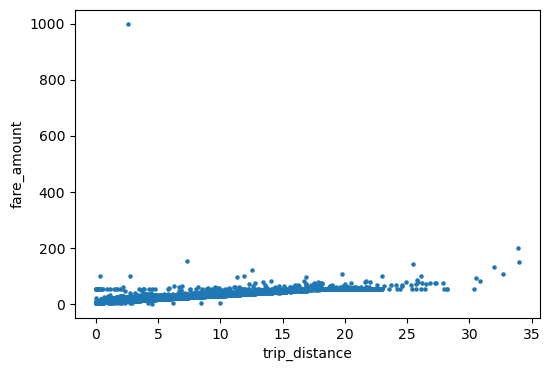

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(data['trip_distance'], data['fare_amount'], s=5)
plt.xlabel('trip_distance')
plt.ylabel('fare_amount')
plt.show()


주행 거리(trip_distance)가 증가할수록 요금(fare_amount)이  
증가하는 경향을 확인하였다.


#### 요금과 주행 시간 관계

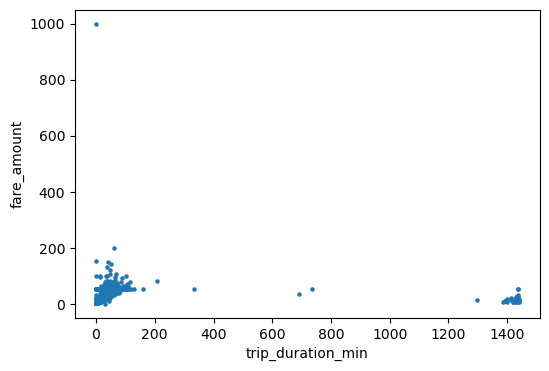

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(data['trip_duration_min'], data['fare_amount'], s=5)
plt.xlabel('trip_duration_min')
plt.ylabel('fare_amount')
plt.show()


주행 시간(trip_duration_min)과 요금(fare_amount) 간의 관계를 통해  
주행 시간이 요금에 영향을 줄 수 있음을 확인하였다.

#### 3-3 결제 수단 분포 확인

In [37]:
data['payment_method'].value_counts()


payment_method
Card    11404
Cash    11096
Name: count, dtype: int64

결제 수단의 분포를 확인하여  
범주형 변수의 데이터 비중을 살펴보았다.


In [38]:
data.groupby('payment_method')['fare_amount'].mean()


payment_method
Card    13.058607
Cash    12.887235
Name: fare_amount, dtype: float64

결제 수단별 평균 요금을 비교하여  
결제 방식에 따른 요금 차이가 있는지 간단히 확인하였다.

요금과 관련된 주요 변수들의 분포와 관계를 탐색하여,  
모델링에 활용 가능한 변수들의 특성을 파악하였다.

